# Customer Segmentation using K-Means Clustering and PCA

Week 5 – Unsupervised Learning & Clustering

This project performs customer segmentation using the Mall Customers dataset.  
K-Means clustering is applied to identify groups of customers based on age, income, and spending behavior.  
Principal Component Analysis (PCA) is also used to visualize clusters in reduced dimensions.

#Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#Dataset Information

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#Check Missing Values

In [6]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


#Basic Data Visualization

Age Distribution

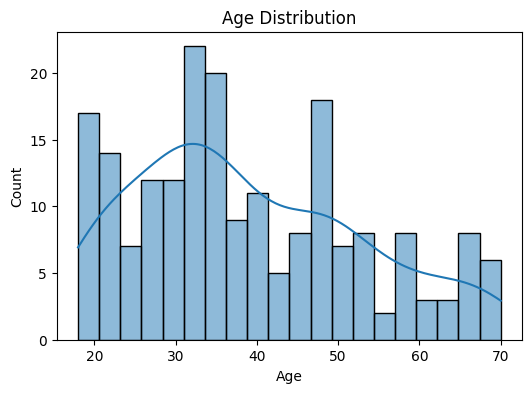

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

Annual Income Distribution

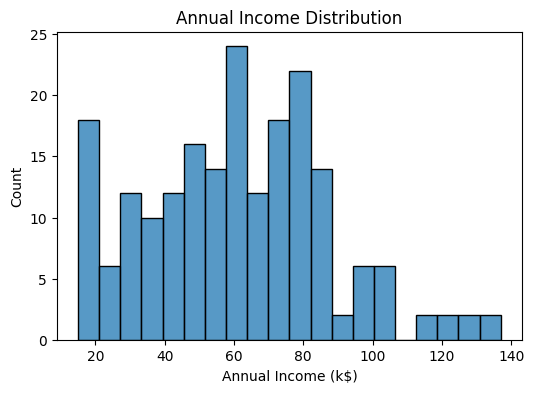

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20)

plt.title("Annual Income Distribution")
plt.show()

Spending Score Distribution

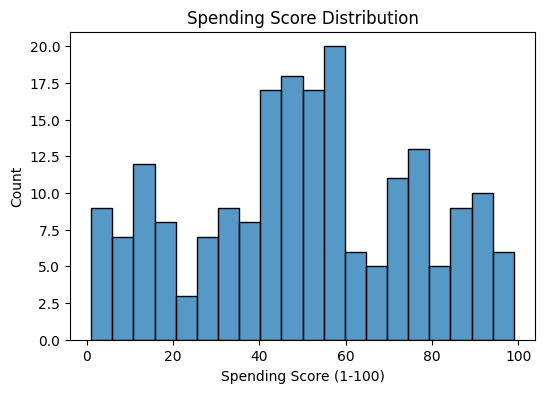

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20)

plt.title("Spending Score Distribution")
plt.show()

#Select Features for Clustering

In [10]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

#Feature Scaling

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#Elbow Method (Find Optimal K)

In [12]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

Elbow Plot

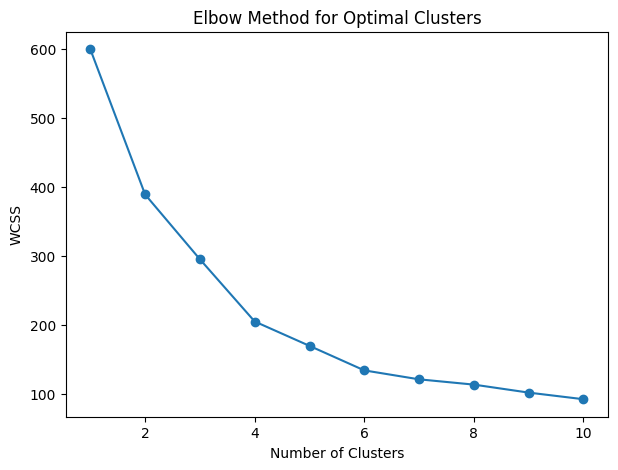

In [13]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

#Apply K-Means Clustering

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


#Visualize Customer Segments

Income vs Spending Score

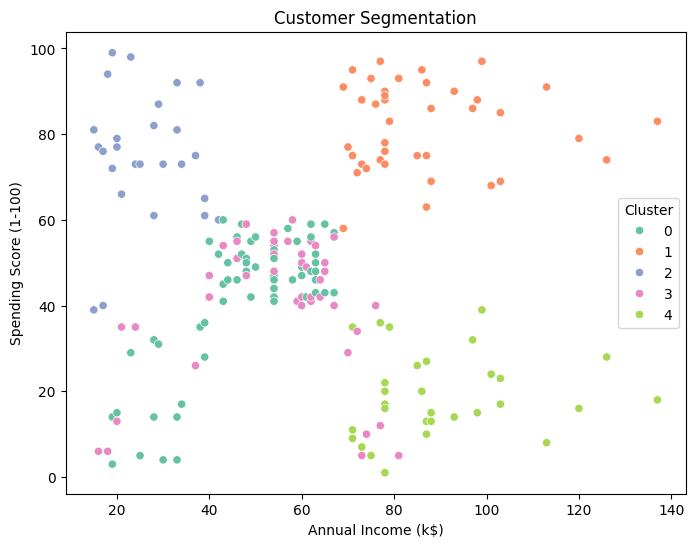

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("Customer Segmentation")
plt.show()

#Cluster Distribution

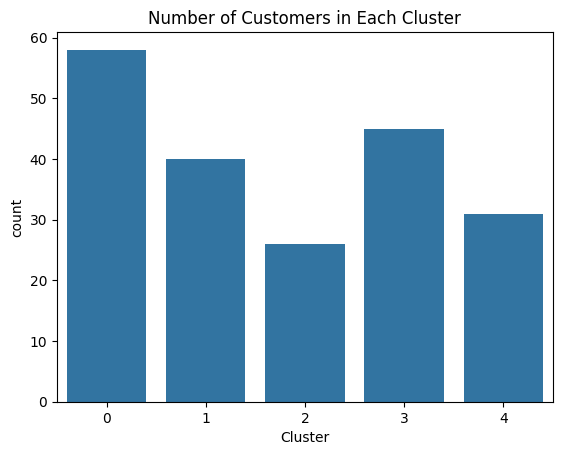

In [16]:
sns.countplot(x=df['Cluster'])

plt.title("Number of Customers in Each Cluster")

plt.show()

#PCA for Dimensionality Reduction

In [17]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:,0]
df['PCA2'] = pca_components[:,1]

PCA Cluster Visualization

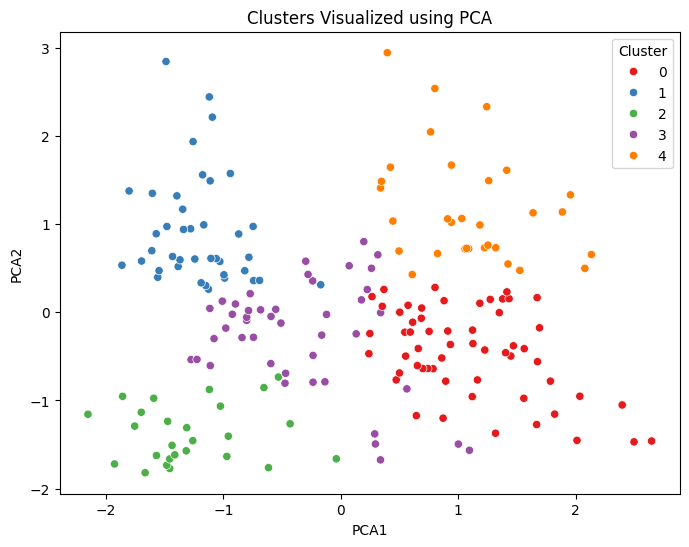

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['PCA1'],
    y=df['PCA2'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Clusters Visualized using PCA")

plt.show()

#Cluster Analysis

In [19]:
df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


#Cluster Interpretation

Cluster 0 → High income, high spending customers (premium customers)

Cluster 1 → Low income, low spending customers

Cluster 2 → Young customers with moderate spending

Cluster 3 → High income but low spending customers

Cluster 4 → Moderate income and high spending customers

#Business Insights

Customer segmentation helps businesses develop targeted marketing strategies:

High-income, high-spending customers can be targeted with premium products and loyalty programs.

Low-income customers may respond better to discounts and promotional offers.

Customers with high income but low spending can be encouraged to spend more through personalized marketing campaigns.

Young customers with moderate spending can be targeted using trend-based products and digital promotions.

Thus, clustering helps companies understand customer behavior and design effective marketing strategies.

## Conclusion

In this project, unsupervised learning techniques were applied to perform customer segmentation using the Mall Customers dataset. K-Means clustering was used to group customers based on key attributes such as age, annual income, and spending score. The Elbow Method helped determine the optimal number of clusters, ensuring meaningful segmentation of customers.

The results revealed distinct customer groups with different spending behaviors and income levels. PCA was also applied to reduce dimensionality and visualize the clusters more clearly in two dimensions.

Customer segmentation provides valuable insights for businesses. By identifying different customer groups, companies can design targeted marketing strategies such as personalized promotions, loyalty programs, and product recommendations. This helps improve customer satisfaction, optimize marketing efforts, and increase overall business revenue.